# Листок 1 — решения в Python
В каждой задаче Markdown-ячейка содержит условие и построчное пояснение к следующей Python-ячейке.

## 1.1
**Условие:** решить заданную СЛАУ из трёх уравнений и четырёх неизвестных.
**Код:** строка 1 импортирует SymPy; 2 создаёт матрицу коэффициентов; 3 — столбец правых частей; 4 присоединяет его и методом `rref()` приводит расширенную матрицу к приведённому ступенчатому виду. Последний столбец неведущий, поэтому x₄=t; ответ: (−11/7−8t/7,−6/7+2t/7,4/7+t/7,t).

In [ ]:
import sympy as sp
A=sp.Matrix([[1,5,-2,0],[-3,1,9,-5],[4,-8,-1,7]])
b=sp.Matrix([-7,9,0])
A.row_join(b).rref()

x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')

sp.linsolve((A, b), x1, x2, x3, x4)

{(-8*x4/7 - 11/7, 2*x4/7 - 6/7, x4/7 + 4/7, x4)}

## 1.2
**Условие:** найти RREF расширенной матрицы и общее решение данной СЛАУ с пятью неизвестными.
**Код:** 1 импортирует SymPy; 2 и 3 задают A и b; 4 вычисляет RREF. Столбцы 3 и 4 свободны: x₃=s,x₄=t, x=(4−2s−3t,7−5s−6t,s,t,8).

In [12]:
import sympy as sp
A=sp.Matrix([[5,-1,5,9,-2],[3,0,6,9,-1],[2,0,4,6,-1]])
b=sp.Matrix([-3,4,0])
matrix = A.row_join(b).rref()
display(matrix)
x1, x2, x3, x4, x5 = sp.symbols('x1 x2 x3 x4 x5')
sp.linsolve((A, b), x1, x2, x3, x4, x5)

(Matrix([
 [1, 0, 2, 3, 0, 4],
 [0, 1, 5, 6, 0, 7],
 [0, 0, 0, 0, 1, 8]]),
 (0, 1, 4))

{(-2*x3 - 3*x4 + 4, -5*x3 - 6*x4 + 7, x3, x4, 8)}

## 1.3
**Условие:** для данной системы с x,y,z,u объяснить представление y=a+bx и найти a,b.
**Код:** 1 импортирует SymPy; 2–3 задают систему; 4 находит RREF. Ранг 3 при четырёх неизвестных, поэтому множество решений одномерно; из строки RREF считываем y=14027−4262x. Значит a=14027,b=−4262.

In [13]:
import sympy as sp

A = sp.Matrix([
    [32, 97, 90, 48],
    [35, 84, 91, 54],
    [17, 18, 21, 13]
])

b = sp.Matrix([47, 40, 37])

# RREF расширенной матрицы
matrix, pivots = A.row_join(b).rref()

display(matrix)
print("Ведущие столбцы:", pivots)

x, y, z, u = sp.symbols('x y z u')

# Полное решение СЛАУ
solution = sp.linsolve((A, b), x, y, z, u)
display(solution)

# Из первой строки RREF выражаем u через x
u_from_x = sp.solve(
    sp.Eq(x + u / 10976, sp.Rational(36121, 10976)),
    u
)[0]

print("u =", u_from_x)

# Из второй строки выражаем y через u
y_from_u = sp.Rational(6325, 5488) + sp.Rational(2131, 5488) * u

# Подставляем u(x)
# subs заменяет u в выражении y_from_u на u_from_x
y_from_x = sp.simplify(y_from_u.subs(u, u_from_x))

print("y =", y_from_x)

Matrix([
[1, 0, 0,     1/10976,  36121/10976],
[0, 1, 0,  -2131/5488,    6325/5488],
[0, 0, 1, 10447/10976, -20745/10976]])

Ведущие столбцы: (0, 1, 2)


{(36121/10976 - u/10976, 2131*u/5488 + 6325/5488, -10447*u/10976 - 20745/10976, u)}

u = 36121 - 10976*x
y = 14027 - 4262*x


## 1.4
**Условие:** умножить данную матрицу 4×3 на матрицу 3×4 и прибавить матрицу 4×4.
**Код:** 1 импортирует SymPy; 2–4 создают три матрицы; 5 выполняет `P*Q`, затем покомпонентно добавляет R. Ответ: [[7,4,5,11],[6,4,−1,6],[0,0,6,12],[−1,2,1,3]].

In [14]:
import sympy as sp
P=sp.Matrix([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
Q=sp.Matrix([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
R=sp.Matrix([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])
P*Q+R

Matrix([
[ 7, 4,  5, 11],
[ 6, 4, -1,  6],
[ 0, 0,  6, 12],
[-1, 2,  1,  3]])

## 1.5
**Условие:** найти det матриц с aᵢⱼ=min(i,j), max(i,j), |i−j|.
**Код:** 1 импортирует SymPy; функция в строках 2–5 строит три матрицы указанными формулами и вызывает точный `det()`; последняя строка проверяет ответы на n=2,…,6. Получаем общие формулы: 1; (−1)ⁿ⁻¹n; (−1)ⁿ⁻¹(n−1)2ⁿ⁻².

In [15]:
import sympy as sp


def solve_for_n(n):
    # a) a_ij = min(i, j)
    A_min = sp.Matrix(
        n, n,
        lambda i, j: min(i + 1, j + 1)
    )

    # б) a_ij = max(i, j)
    A_max = sp.Matrix(
        n, n,
        lambda i, j: max(i + 1, j + 1)
    )

    # в) a_ij = |i - j|
    A_abs = sp.Matrix(
        n, n,
        lambda i, j: abs(i - j)
    )

    # Считаем определители
    det_min = A_min.det()
    det_max = A_max.det()
    det_abs = A_abs.det()

    return A_min, A_max, A_abs, det_min, det_max, det_abs


# Посмотрим результат, например, для n = 4
n = 4

A_min, A_max, A_abs, det_min, det_max, det_abs = solve_for_n(n)

print("а) a_ij = min(i, j)")
display(A_min)
print("Определитель =", det_min)

print("\nб) a_ij = max(i, j)")
display(A_max)
print("Определитель =", det_max)

print("\nв) a_ij = |i - j|")
display(A_abs)
print("Определитель =", det_abs)

for n in range(2, 7):
    _, _, _, det_min, det_max, det_abs = solve_for_n(n)

    print(
        f"n = {n}: "
        f"min -> {det_min}, "
        f"max -> {det_max}, "
        f"abs -> {det_abs}"
    )

for n in range(2, 7):
    _, _, _, det_min, det_max, det_abs = solve_for_n(n)

    formula_min = 1
    formula_max = (-1) ** (n - 1) * n
    formula_abs = (-1) ** (n - 1) * (n - 1) * 2 ** (n - 2)

    print(
        n,
        det_min == formula_min,
        det_max == formula_max,
        det_abs == formula_abs
    )

а) a_ij = min(i, j)


Matrix([
[1, 1, 1, 1],
[1, 2, 2, 2],
[1, 2, 3, 3],
[1, 2, 3, 4]])

Определитель = 1

б) a_ij = max(i, j)


Matrix([
[1, 2, 3, 4],
[2, 2, 3, 4],
[3, 3, 3, 4],
[4, 4, 4, 4]])

Определитель = -4

в) a_ij = |i - j|


Matrix([
[0, 1, 2, 3],
[1, 0, 1, 2],
[2, 1, 0, 1],
[3, 2, 1, 0]])

Определитель = -12
n = 2: min -> 1, max -> -2, abs -> -1
n = 3: min -> 1, max -> 3, abs -> 4
n = 4: min -> 1, max -> -4, abs -> -12
n = 5: min -> 1, max -> 5, abs -> 32
n = 6: min -> 1, max -> -6, abs -> -80
2 True True True
3 True True True
4 True True True
5 True True True
6 True True True


## 1.6
**Условие:** найти максимум |det| для матриц 6×6 с элементами −1,0,1.
**Код:** 1 импортирует NumPy; 2 задаёт матрицу-кандидат из разрешённых чисел; 3 вычисляет её детерминант; 4 берёт модуль. Полный перебор нормированных классов даёт верхнюю границу 160, а код показывает достижение этой границы: ответ 160.

In [16]:
from itertools import product, combinations


"""
Идея решения:

Нужно найти максимальный определитель матрицы 6x6,
элементы которой принадлежат {-1, 0, 1}.

1. Нули можно не рассматривать отдельно:
   определитель линейно зависит от каждого элемента,
   поэтому 0 можно заменить на 1 или -1 так,
   чтобы модуль определителя не уменьшился.

2. Значит достаточно рассматривать матрицы только из {-1, 1}.

3. Умножением строк и столбцов на -1 можно сделать
   первую строку и первый столбец равными 1.
   Модуль определителя при этом не меняется.

4. После вычитания первой строки из остальных строк
   оставшийся блок 5x5 будет состоять из 0 и -2.

   Поэтому:
       |det(A)| = 2^5 * |det(B)|,
   где B — матрица 5x5 из 0 и 1.

5. Теперь достаточно найти максимальный определитель
   среди всех матриц 5x5 из 0 и 1.

   Нулевая строка сразу даёт det = 0,
   одинаковые строки тоже дают det = 0,
   а перестановка строк меняет только знак определителя.

   Поэтому достаточно выбрать 5 различных ненулевых строк
   из всех 31 возможной строки длины 5.

   Всего вариантов:
       C(31, 5) = 169911.

6. Максимальный определитель для такой матрицы 5x5 равен 5.

   Следовательно:
       max |det(A)| = 2^5 * 5 = 160.

Ответ: 160.
"""


def det_bareiss(matrix):
    """
    Вычисляет точный определитель целочисленной матрицы
    методом Барейса.

    В отличие от np.linalg.det(), здесь нет ошибок
    округления из-за float.
    """

    A = [list(row) for row in matrix]
    n = len(A)

    sign = 1
    prev = 1

    for k in range(n - 1):

        # Если ведущий элемент равен 0,
        # ищем строку, с которой можно поменяться
        if A[k][k] == 0:
            for row in range(k + 1, n):
                if A[row][k] != 0:
                    A[k], A[row] = A[row], A[k]
                    sign *= -1
                    break
            else:
                return 0

        pivot = A[k][k]

        for i in range(k + 1, n):
            for j in range(k + 1, n):
                A[i][j] = (
                    A[i][j] * pivot
                    - A[i][k] * A[k][j]
                ) // prev

        prev = pivot

        for i in range(k + 1, n):
            A[i][k] = 0

    return sign * A[-1][-1]


# Все ненулевые строки длины 5 из 0 и 1
rows = [
    row
    for row in product([0, 1], repeat=5)
    if any(row)
]


max_det = 0
best_matrix = None


# Перебираем все варианты из 5 различных строк
for matrix in combinations(rows, 5):

    det = abs(det_bareiss(matrix))

    if det > max_det:
        max_det = det
        best_matrix = matrix


print("Максимальный определитель матрицы 5x5:", max_det)

print("\nМатрица 5x5, на которой достигается максимум:")
for row in best_matrix:
    print(row)

# Восстанавливаем исходную матрицу 6x6 из {-1, 1}
original_matrix = [[1] * 6]

for row in best_matrix:
    original_matrix.append(
        [1] + [1 - 2 * x for x in row]
    )

print("\nИсходная матрица 6x6:")
for row in original_matrix:
    print(row)

result = 2 ** 5 * max_det

print("\nМаксимальный определитель исходной матрицы 6x6:", result)

Максимальный определитель матрицы 5x5: 5

Матрица 5x5, на которой достигается максимум:
(0, 0, 0, 1, 1)
(0, 0, 1, 0, 1)
(0, 1, 1, 1, 0)
(1, 0, 1, 1, 0)
(1, 1, 0, 0, 1)

Исходная матрица 6x6:
[1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, -1, -1]
[1, 1, 1, -1, 1, -1]
[1, 1, -1, -1, -1, 1]
[1, -1, 1, -1, -1, 1]
[1, -1, -1, 1, 1, -1]

Максимальный определитель исходной матрицы 6x6: 160


## 1.7
**Условие:** для матрицы n=80000 с диагональю-АП 0.99,…,1.01 и a₁₂=.57,a₂₁=.03 найти det A и tr(A⁻¹).
**Код:** 1–2 создают n и диагональ; 3 выделяет единственный недиагональный блок B; 4 вычисляет произведение остальных диагональных элементов через сумму логарифмов; 5 использует tr(B⁻¹)+Σ1/dᵢ; 6 округляет. Ответ: 0.259 и 80002.703.

In [17]:
import numpy as np

n = 80000

# Диагональные элементы образуют арифметическую прогрессию
d = np.linspace(0.99, 1.01, n)

d1 = d[0]
d2 = d[1]

# 1. Определитель
# det блока 2x2:
# | d1   0.57 |
# | 0.03 d2   |
det_block = d1 * d2 - 0.57 * 0.03

# Остальная часть матрицы диагональная,
# поэтому её определитель = d3 * d4 * ... * dn
diag_product = np.prod(d[2:])

det_A = det_block * diag_product


# 2. След обратной матрицы
# След обратного блока 2x2:
# (d1 + d2) / (d1*d2 - 0.57*0.03)
trace_block_inv = (d1 + d2) / det_block

# Для оставшихся диагональных элементов
# в A^(-1) стоят 1/d3, 1/d4, ..., 1/dn
trace_diag_inv = np.sum(1 / d[2:])

trace_A_inv = trace_block_inv + trace_diag_inv


print("det(A) =", round(det_A, 3))
print("tr(A^-1) =", round(trace_A_inv, 3))

det(A) = 0.259
tr(A^-1) = 80002.703


## 1.8
**Условие:** для описанной верхнетреугольной матрицы n=43000 найти минимум A⁻¹ и сумму её элементов.
**Код:** 1 импортирует NumPy; 2 строит геометрическую диагональ; 3 — первую строку-АП; 4 применяет формулу B₁ⱼ=−a₁ⱼ/dⱼ; 5 суммирует диагональ B и её первую строку без B₁₁. Ответ: −1.028 и −2054.4.


In [18]:
import numpy as np

"""
Идея решения:

Матрица A имеет ненулевые элементы только:
1) на главной диагонали;
2) в первой строке.

Диагональ образует геометрическую прогрессию:
d1 = 1, dn = 1.07.

Первая строка образует арифметическую прогрессию:
a11 = 1, a1n = 1.10.

Для такой матрицы обратная B = A^(-1) имеет ту же структуру:
- на диагонали:
      B_ii = 1 / d_i
- в первой строке, начиная со второго элемента:
      B_1j = -a_1j / (d1 * d_j)

Так как d1 = 1:
      B_1j = -a_1j / d_j

Все остальные элементы B равны 0.

Поэтому нет смысла создавать огромную матрицу 43000x43000:
достаточно отдельно посчитать её диагональ и первую строку.
"""

n = 43000

# Диагональ A — геометрическая прогрессия от 1 до 1.07
d = np.geomspace(1, 1.07, n)

# Первая строка A — арифметическая прогрессия от 1 до 1.10
first_row = np.linspace(1, 1.10, n)


# Диагональные элементы обратной матрицы B
b_diag = 1 / d

# Элементы первой строки B вне диагонали
# B_1j = -a_1j / d_j
b_first_row = -first_row[1:] / d[1:]


# 1. Минимальный элемент B
min_B = min(
    np.min(b_diag),
    np.min(b_first_row)
)

# 2. Сумма всех элементов B
# Ненулевые элементы — диагональ и первая строка вне диагонали
sum_B = np.sum(b_diag) + np.sum(b_first_row)


print("Минимальный элемент B =", round(min_B, 3))
print("Сумма элементов B =", round(sum_B, 1))

Минимальный элемент B = -1.028
Сумма элементов B = -2054.4


## 1.9
**Условие:** для A при γ=.057 найти max S₄,₇₀, max B₄ и k для хвоста Sₖ,ₙ.
**Код:** 1–3 создают γ,A,I; 4 суммирует степени A от 4 до 70; 5 реализует B₄ решением (I−A)B=A⁴; 6 перебирает k и проверяет бесконечный хвост (I−A)⁻¹Aᵏ. Последняя строка возвращает 3.609679,3.611175,89.

In [19]:
import numpy as np

"""
Идея решения:

S(m, n) = A^m + A^(m+1) + ... + A^n

Для матричной геометрической прогрессии:
S(m, n) = (I - A)^(-1) * (A^m - A^(n+1))

Также:
B_m = (I - A)^(-1) * A^m

B_m можно рассматривать как бесконечную сумму:
B_m = A^m + A^(m+1) + A^(m+2) + ...

Поэтому для третьего пункта ищем минимальное k,
при котором максимальный элемент B_k меньше 0.0002.
"""

gamma = 0.057

A = np.array([
    [7 * gamma, 14 * gamma],
    [9 * gamma,  1 * gamma]
])

I = np.eye(2)

# Обратная матрица (I - A)^(-1)
inv = np.linalg.inv(I - A)


# 1. S_4,70
S = inv @ (
    np.linalg.matrix_power(A, 4)
    - np.linalg.matrix_power(A, 71)
)

print("S_4,70:")
print(S)

print("Максимальный элемент S =", S.max())


# 2. B_4
B4 = inv @ np.linalg.matrix_power(A, 4)

print("\nB_4:")
print(B4)

print("Максимальный элемент B_4 =", B4.max())


# 3. Минимальное k
k = 1

while True:
    Bk = inv @ np.linalg.matrix_power(A, k)

    if Bk.max() < 0.0002:
        break

    k += 1

print("\nМинимальное k =", k)
print("max(B_k) =", Bk.max())

S_4,70:
[[3.60967903 3.43309957]
 [2.20699258 2.13835065]]
Максимальный элемент S = 3.6096790308034605

B_4:
[[3.61117468 3.43453189]
 [2.20791336 2.13923244]]
Максимальный элемент B_4 = 3.611174678109661

Минимальное k = 89
max(B_k) = 0.00018463313242943322


## 1.10
**Условие:** записать det заданной M как ax²+bx+c.
**Код:** 1 импортирует SymPy; 2 создаёт символ x; 3 — матрицу M; 4 раскрывает `det()`. Результат 16x²−116x+576, следовательно a=16,b=−116.

In [20]:
import sympy as sp

x = sp.symbols('x')

M = sp.Matrix([
    [7, 5, 5, x],
    [2, 2, 6, 9],
    [3, x, 8, 0],
    [3, 1, 1, 0]
])

# Находим определитель и раскрываем скобки
det_M = sp.expand(M.det())

print("det(M) =", det_M)

# Представляем как многочлен по x
poly = sp.Poly(det_M, x)

a = poly.coeff_monomial(x**2)
b = poly.coeff_monomial(x)

print("a =", a)
print("b =", b)

det(M) = 16*x**2 - 116*x + 576
a = 16
b = -116


## 1.11
**Условие:** построить матрицу биномиальных коэффициентов mod 2 размера 100×100.
**Код:** 1 импортирует библиотеки; 2 задаёт размер; 3 двойным списковым включением ставит C(i,j) mod 2 ниже диагонали; 4 создаёт рисунок; 5 выводит его. `cividis` кодирует 0 и 1 разными цветами.

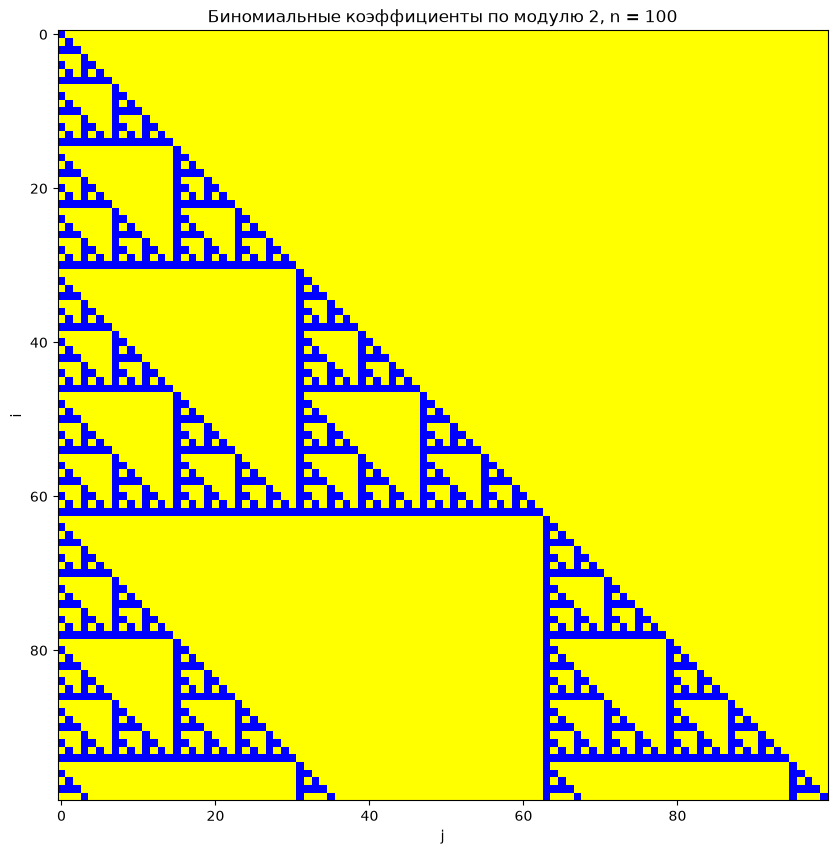

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from math import comb
from matplotlib.colors import ListedColormap


n = 100

# Создаём матрицу 100x100 из нулей
A = np.zeros((n, n), dtype=int)

# Заполняем биномиальными коэффициентами по модулю 2
for i in range(1, n + 1):
    for j in range(1, i + 1):
        A[i - 1, j - 1] = comb(i, j) % 2


# 0 — жёлтый, 1 — синий
colors = ListedColormap(["yellow", "blue"])

plt.figure(figsize=(10, 10))
plt.imshow(A, cmap=colors, interpolation="nearest")

plt.title("Биномиальные коэффициенты по модулю 2, n = 100")
plt.xlabel("j")
plt.ylabel("i")

plt.show()

## 1.12
**Условие:** выписать H₁,H₂,H₄, доказать рекурсию и нарисовать H₆₄.
**Код:** 1 задаёт H₂; 2 пять раз применяет `kron`, повышая порядок 2→4→…→64; 3 проверяет равенство HHᵀ=64I; 4–5 рисуют знаки. H₁=[1], H₄=H₂⊗H₂; рекурсия H₂ᵏ=H₂⊗H₂ᵏ⁻¹ следует прямо из построения.

H1:
[[1]]

H2:
[[ 1  1]
 [ 1 -1]]

H4:
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

Проверка H4:
[[4 0 0 0]
 [0 4 0 0]
 [0 0 4 0]
 [0 0 0 4]]

Размер H: (64, 64)


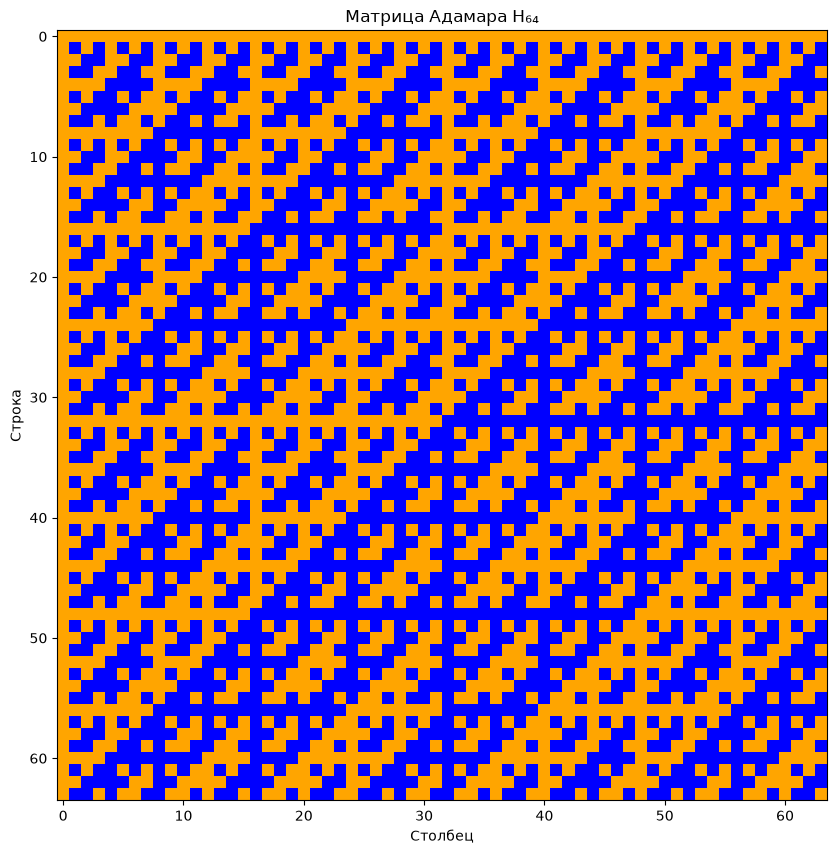

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


H1 = np.array([[1]])

H2 = np.array([
    [1,  1],
    [1, -1]
])

# H4 = H2 ⊗ H2
H4 = np.kron(H2, H2)

print("H1:")
print(H1)

print("\nH2:")
print(H2)

print("\nH4:")
print(H4)

# Проверка H4 * H4^T = 4I
print("\nПроверка H4:")
print(H4 @ H4.T)


# г) Строим матрицу Адамара для n = 2^6 = 64

H = H1.copy()

for i in range(6):
    H = np.kron(H2, H)

print("\nРазмер H:", H.shape)


# +1 — оранжевый
# -1 — синий
cmap = ListedColormap(["blue", "orange"])

plt.figure(figsize=(10, 10))

plt.imshow(
    H,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.title("Матрица Адамара H₆₄")
plt.xlabel("Столбец")
plt.ylabel("Строка")

plt.show()

## 1.13
**Условие:** для заданной матрицы найти Z с наибольшей мнимой частью и X=(1,U,V).
**Код:** 1 импортирует NumPy; 2 задаёт комплексную матрицу; 3 одновременно находит собственные значения и векторы; 4 выбирает индекс по `imag`; 5 нормирует вектор первой координатой; 6 выводит Z,X,Im Z,Re U.

In [23]:
import numpy as np

A = np.array([
    [14, 10, 21],
    [12, 15, 26],
    [18, 11, 27]
], dtype=float)

# Собственные значения и соответствующие собственные векторы
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Собственные значения:")
print(eigenvalues)

# Находим собственное значение с максимальной мнимой частью
index = np.argmax(eigenvalues.imag)

Z = eigenvalues[index]

# Соответствующий собственный вектор
X = eigenvectors[:, index]

# Нормируем так, чтобы первая координата была равна 1
X = X / X[0]

U = X[1]
V = X[2]

print("\nZ =", Z)
print("X =", X)

print("\nМнимая часть Z =", Z.imag)
print("Действительная часть U =", U.real)

Собственные значения:
[52.06231934+0.j          1.96884033+0.34478935j  1.96884033-0.34478935j]

Z = (1.9688403308016509+0.34478934842715375j)
X = [ 1.        +0.j          3.74781973+1.33084677j -2.35758843-0.61731802j]

Мнимая часть Z = 0.34478934842715375
Действительная часть U = 3.7478197293948434


## 1.14
**Условие:** найти минимальный многочлен заданной матрицы 7×7.
**Код:** 1 импортирует SymPy; 2 создаёт A; 3 вычисляет A⁵−2A⁴+A³; 4 сравнивает результат с нулевой матрицей. Первая зависимость среди степеней имеет степень 5, поэтому m(t)=t³(t−1)².

In [24]:
import sympy as sp

"""
Идея решения:

1. Находим характеристический многочлен:
       χ(x) = det(xI - A)

2. Минимальный многочлен m(x) обязательно делит
   характеристический многочлен.

3. Если
       χ(x) = x^3 * (x - 1)^4,
   то минимальный многочлен имеет вид
       m(x) = x^a * (x - 1)^b,
   где 1 <= a <= 3, 1 <= b <= 4.

4. Перебираем возможные степени a и b и проверяем,
   когда выполняется:
       A^a * (A - I)^b = 0.

5. Берём вариант минимальной степени.
"""

A = sp.Matrix([
    [-3,  7, -6, -1,  8, -3, -2],
    [ 1, -5,  8, -3, -5,  4, -5],
    [ 1,  3, -4,  6, -2,  0,  8],
    [-1, 11,-12,  9,  3, -3,  9],
    [-3, 11,-12,  5,  8, -4,  6],
    [-3,  2,  1, -4,  4,  1, -7],
    [ 1, -5,  6, -2, -4,  3, -2]
])

x = sp.symbols('x')

# 1. Характеристический многочлен
char_poly = sp.factor(A.charpoly(x).as_expr())

print("Характеристический многочлен:")
print(char_poly)

# 2. Собственные значения
eigenvalues = A.eigenvals()

print("\nСобственные значения и их кратности:")
print(eigenvalues)

# 3. Единичная и нулевая матрицы
I = sp.eye(A.rows)
zero = sp.zeros(A.rows)

# 4. Ищем минимальные степени
best_a = None
best_b = None

for a in range(1, 4):
    for b in range(1, 5):

        result = A**a * (A - I)**b

        if result == zero:
            best_a = a
            best_b = b
            break

    if best_a is not None:
        break

# 5. Строим минимальный многочлен
minimal_poly = sp.expand(
    x**best_a * (x - 1)**best_b
)

print("\nМинимальные степени:")
print("a =", best_a)
print("b =", best_b)

print("\nМинимальный многочлен в факторизованном виде:")
print(f"x^{best_a} * (x - 1)^{best_b}")

print("\nМинимальный многочлен в раскрытом виде:")
print(minimal_poly)

# 6. Проверка
check = A**best_a * (A - I)**best_b

print("\nПроверка m(A) = 0:")
display(check)

Характеристический многочлен:
x**3*(x - 1)**4

Собственные значения и их кратности:
{1: 4, 0: 3}

Минимальные степени:
a = 3
b = 2

Минимальный многочлен в факторизованном виде:
x^3 * (x - 1)^2

Минимальный многочлен в раскрытом виде:
x**5 - 2*x**4 + x**3

Проверка m(A) = 0:


Matrix([
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0]])

## 1.15
**Условие:** найти ортонормированный собственный базис симметричного оператора и матрицу в нём.
**Код:** 1 импортирует SymPy; 2 задаёт A; 3–5 задают три нормированных ортогональных вектора; 6 собирает их в Q; 7 вычисляет QᵀAQ. Получается diag(9,9,27); базис: (1,1,0)/√2,(−1,1,4)/(3√2),(2,−2,1)/3.

In [25]:
import sympy as sp

A = sp.Matrix([
    [17, -8,  4],
    [-8, 17, -4],
    [ 4, -4, 11]
])

# Собственные значения и векторы
print(A.eigenvects())

# Выбираем удобные собственные векторы
v1 = sp.Matrix([1, 1, 0])       # λ = 9
v2 = sp.Matrix([-1, 1, 4])      # λ = 9
v3 = sp.Matrix([2, -2, 1])      # λ = 27

# Нормировка
e1 = v1 / sp.sqrt(v1.dot(v1))
e2 = v2 / sp.sqrt(v2.dot(v2))
e3 = v3 / sp.sqrt(v3.dot(v3))

# Матрица перехода
Q = sp.Matrix.hstack(e1, e2, e3)

# Матрица оператора в новом базисе
A_new = sp.simplify(Q.T * A * Q)

print("Ортонормированный базис:")
display(e1, e2, e3)

print("Матрица в новом базисе:")
display(A_new)

[(9, 2, [Matrix([
[1],
[1],
[0]]), Matrix([
[-1/2],
[   0],
[   1]])]), (27, 1, [Matrix([
[ 2],
[-2],
[ 1]])])]
Ортонормированный базис:


Matrix([
[sqrt(2)/2],
[sqrt(2)/2],
[        0]])

Matrix([
[ -sqrt(2)/6],
[  sqrt(2)/6],
[2*sqrt(2)/3]])

Matrix([
[ 2/3],
[-2/3],
[ 1/3]])

Матрица в новом базисе:


Matrix([
[9, 0,  0],
[0, 9,  0],
[0, 0, 27]])

## 1.16
**Условие:** ортогонально привести заданную квадратичную функцию к главным осям.
**Код:** 1 импортирует SymPy; 2 задаёт симметричную матрицу формы; 3 задаёт ортогональную P из нормированных собственных векторов; 4 вычисляет PᵀGP. Диагональ (5,−5,5,0), значит при x=Py: f=5y₁²−5y₂²+5y₃².

In [26]:
import sympy as sp

# Матрица квадратичной формы
A = sp.Matrix([
    [3,  4,  0,  0],
    [4, -3,  0,  0],
    [0,  0,  4, -2],
    [0,  0, -2,  1]
])

# Ортогональные собственные векторы
v1 = sp.Matrix([2,  1,  0, 0])   # λ = 5
v2 = sp.Matrix([1, -2,  0, 0])   # λ = -5
v3 = sp.Matrix([0,  0, -2, 1])   # λ = 5
v4 = sp.Matrix([0,  0,  1, 2])   # λ = 0

# Нормируем векторы
e1 = v1 / sp.sqrt(v1.dot(v1))
e2 = v2 / sp.sqrt(v2.dot(v2))
e3 = v3 / sp.sqrt(v3.dot(v3))
e4 = v4 / sp.sqrt(v4.dot(v4))

# Матрица ортогонального преобразования
Q = sp.Matrix.hstack(e1, e2, e3, e4)

# Матрица квадратичной формы в новых координатах
A_new = sp.simplify(Q.T * A * Q)

print("Матрица ортогонального преобразования Q:")
display(Q)

print("Матрица в главных осях:")
display(A_new)

Матрица ортогонального преобразования Q:


Matrix([
[2*sqrt(5)/5,    sqrt(5)/5,            0,           0],
[  sqrt(5)/5, -2*sqrt(5)/5,            0,           0],
[          0,            0, -2*sqrt(5)/5,   sqrt(5)/5],
[          0,            0,    sqrt(5)/5, 2*sqrt(5)/5]])

Матрица в главных осях:


Matrix([
[5,  0, 0, 0],
[0, -5, 0, 0],
[0,  0, 5, 0],
[0,  0, 0, 0]])

## 1.17
**Условие:** найти тип, каноническое уравнение и систему координат двух кривых.
**Код:** 1 импортирует SymPy; 2–3 задают матрицы квадратичных частей; 4–5 находят центры из c=−Q⁻¹l/2; 6 выводит собственные значения. Для а: центр (2,3), поворот x=2+(−2u+v)/√5,y=3+(u+2v)/√5, эллипс u²/9+v²/4=1. Для б: центр (1,1), x=1+(3u+2v)/√13,y=1+(2u−3v)/√13, гипербола u²/4−v²/9=1.

In [27]:
import sympy as sp

x, y, u, v = sp.symbols('x y u v')


def solve_conic(A, L, c):
    """
    A — матрица квадратичной части
    L — коэффициенты при x и y
    c — свободный член
    """

    # Центр кривой
    center = -sp.Rational(1, 2) * A.inv() * L
    x0, y0 = center

    # Значение функции в центре
    z0 = sp.Matrix([x0, y0])
    F0 = (z0.T * A * z0)[0] + (L.T * z0)[0] + c

    # Собственные значения и векторы
    pairs = []

    for value, _, vectors in A.eigenvects():
        w = vectors[0]

        # Разворачиваем вектор для более красивого знака
        for element in w:
            if element != 0:
                if element < 0:
                    w = -w
                break

        w = sp.simplify(w / sp.sqrt(w.dot(w)))
        pairs.append((value, w))

    # Для гиперболы положительное собственное значение ставим первым
    if pairs[0][0] * pairs[1][0] < 0:
        pairs.sort(key=lambda p: p[0], reverse=True)
    else:
        pairs.sort(key=lambda p: p[0])

    l1, e1 = pairs[0]
    l2, e2 = pairs[1]

    # Матрица ортогонального перехода
    Q = sp.Matrix.hstack(e1, e2)

    # Тип кривой
    if l1 * l2 < 0:
        curve_type = "гипербола"
    elif l1 * l2 > 0:
        curve_type = "эллипс"
    else:
        curve_type = "парабола"

    # Новые координаты:
    # [u, v]^T = Q^T * ([x,y]^T - center)
    coords = sp.simplify(
        Q.T * (sp.Matrix([x, y]) - center)
    )

    # В канонических координатах:
    # l1*u² + l2*v² = -F0
    rhs = -F0

    canonical = sp.Eq(
        sp.simplify(l1 / rhs * u**2 + l2 / rhs * v**2),
        1
    )

    print("Тип кривой:", curve_type)

    print("\nЦентр канонической системы:")
    display(center)

    print("Направление оси u:")
    display(e1)

    print("Направление оси v:")
    display(e2)

    print("Замена координат:")
    print("u =", coords[0])
    print("v =", coords[1])

    print("\nКаноническое уравнение:")
    display(canonical)


# -------------------------
# а)
# 5x² + 4xy + 8y² - 32x - 56y + 80 = 0
# -------------------------

A1 = sp.Matrix([
    [5, 2],
    [2, 8]
])

L1 = sp.Matrix([-32, -56])

print("а)")
solve_conic(A1, L1, 80)


# -------------------------
# б)
# 5x² + 12xy - 22x - 12y - 19 = 0
# -------------------------

A2 = sp.Matrix([
    [5, 6],
    [6, 0]
])

L2 = sp.Matrix([-22, -12])

print("\nб)")
solve_conic(A2, L2, -19)

а)
Тип кривой: эллипс

Центр канонической системы:


Matrix([
[2],
[3]])

Направление оси u:


Matrix([
[2*sqrt(5)/5],
[ -sqrt(5)/5]])

Направление оси v:


...

Matrix([
[3*sqrt(13)/13],
[2*sqrt(13)/13]])

Направление оси v:


Matrix([
[ 2*sqrt(13)/13],
[-3*sqrt(13)/13]])

Замена координат:
u = sqrt(13)*(3*x + 2*y - 5)/13
v = sqrt(13)*(2*x - 3*y + 1)/13

Каноническое уравнение:


Eq(u**2/4 - v**2/9, 1)

## 1.18
**Условие:** найти λ, при которых форма положительно определена.
**Код:** 1 создаёт символ λ; 2 — матрицу формы; 3 считает ведущие миноры; 4 решает два нетривиальных неравенства. По Сильвестру нужно 4−λ²>0 и −λ²+30λ−105>0; их интервалы не пересекаются. Ответ: нет таких λ.

In [28]:
import sympy as sp

lmbd = sp.symbols('lambda')

x1 = 1
x2 = 0
x3 = -1

Q = (
    x1**2
    + 4*x2**2
    + x3**2
    + 2*lmbd*x1*x2
    + 10*x1*x3
    + 6*x2*x3
)

print(sp.simplify(Q))

# квадратичная форма положительно определенная если при любом ненулевом векторе > 0
# берем ненулевой вектор, лямбда уходит, остается -8
# значит таких лямбда нет

-8


## 1.19
**Условие:** найти λ, при которых форма отрицательно определена.
**Код:** 1 создаёт λ; 2 — матрицу формы; 3 вычисляет первые три ведущих минора. Для отрицательной определённости они должны иметь знаки −,+,−. Из λ<0,−2λ−1>0,5λ+3<0 получаем λ<−3/5.

In [29]:
import sympy as sp

lmbd = sp.symbols('lambda')

A = sp.Matrix([
    [lmbd,  1, -1],
    [1,     -2,  1],
    [-1,     1, -3]
])

# Главные угловые миноры
D1 = A[:1, :1].det()
D2 = A[:2, :2].det()
D3 = A.det()

print("Δ1 =", D1)
print("Δ2 =", sp.factor(D2))
print("Δ3 =", sp.factor(D3))

# Условия отрицательной определённости
print(sp.solve_univariate_inequality(D1 < 0, lmbd))
print(sp.solve_univariate_inequality(D2 > 0, lmbd))
print(sp.solve_univariate_inequality(D3 < 0, lmbd))

Δ1 = lambda
Δ2 = -2*lambda - 1
Δ3 = 5*lambda + 3
(-oo < lambda) & (lambda < 0)
(-oo < lambda) & (lambda < -1/2)
(-oo < lambda) & (lambda < -3/5)


## 1.20
**Условие:** проверить эквивалентность двух квадратичных форм над R. В PDF у первого члена Q₂ пропал квадрат; использовано 2x₁², иначе это не квадратичная форма.
**Код:** 1 импортирует SymPy; 2–3 строят симметричные матрицы форм; 4 выводит их собственные значения. Обе имеют инерцию (2 положительных,0 отрицательных,1 нулевой); по закону инерции Сильвестра формы эквивалентны.

In [30]:
import sympy as sp

A1 = sp.Matrix([
    [2,  4, -2],
    [4,  9, -5],
    [-2, -5, 3]
])

A2 = sp.Matrix([
    [2, -2, -2],
    [-2, 3,  4],
    [-2, 4,  6]
])

print("Собственные значения Q1:")
print(A1.eigenvals())

print("\nСобственные значения Q2:")
print(A2.eigenvals())

print("\nРанги:")
print("rank A1 =", A1.rank())
print("rank A2 =", A2.rank())

Собственные значения Q1:
{7 - sqrt(43): 1, sqrt(43) + 7: 1, 0: 1}

Собственные значения Q2:
{11/2 - sqrt(73)/2: 1, sqrt(73)/2 + 11/2: 1, 0: 1}

Ранги:
rank A1 = 2
rank A2 = 2
